In [2]:
!pip install -U pip
!pip install -U setuptools wheel
!pip install autogluon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 74.0.0
    Uninstalling setuptools-74.0.0:
      Successfully uninstalled setuptools-74.0.0


In [3]:
import pandas as pd
from autogluon.tabular import TabularDataset, TabularPredictor

/home/ai/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
malicious_odroid1 = pd.read_csv('synthetic_odroid1.csv')
malicious_odroid1['label'] = malicious_odroid1['label'].apply(lambda x: 'malicious_odroid1')

In [6]:
odroid1 = pd.read_csv('vec21/odroid1_carbonyl_onscreen_VEC21.csv')
odroid2 = pd.read_csv('vec21/odroid2_carbonyl_onscreen_VEC21.csv')
rpi_8b = pd.read_csv('vec21/rpi_8b_carbonyl_onscreen_VEC21.csv')
rpi_8c = pd.read_csv('vec21/rpi_8c_carbonyl_onscreen_VEC21.csv')

In [7]:
df = pd.concat([odroid1.iloc[:1000], odroid2.iloc[:1000], rpi_8b[:1000], rpi_8c[:1000], malicious_odroid1[:400]])
df = df.sample(frac=1).reset_index(drop=True)

In [8]:
train_data = TabularDataset(df.iloc[:3800])
test_data = TabularDataset(df.iloc[3801:])

predictor = TabularPredictor(label='label').fit(train_data=train_data, presets='medium_quality')
predictions = predictor.predict(test_data)


No path specified. Models will be saved in: "AutogluonModels/ag-20240905_050727"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.1.99-1 (2024-07-15)
CPU Count:          12
Memory Avail:       11.55 GB / 15.86 GB (72.8%)
Disk Space Avail:   46.75 GB / 96.93 GB (48.2%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240905_050727"
Train Data Rows:    3800
Train Data Columns: 21
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	5 unique label values:  ['odroid2', 'odroid1', 'rpi_8b', 'rpi_8c', 'malicious_odroid1']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may spec

In [9]:
malicious_odroid2 = pd.read_csv('synthetic_odroid2.csv')
predictions = predictor.predict(malicious_odroid2)

In [10]:
predictions

0      malicious_odroid1
1      malicious_odroid1
2                odroid2
3      malicious_odroid1
4      malicious_odroid1
             ...        
495    malicious_odroid1
496              odroid2
497              odroid2
498              odroid1
499    malicious_odroid1
Name: label, Length: 500, dtype: object

In [19]:
true, false = (0,0)
for pred in predictions:
    if pred == 'odroid2':
        true += 1
    else:
        false +=1

In [20]:
true

182

In [21]:
false

318

In [22]:
182/500

0.364

<Axes: >

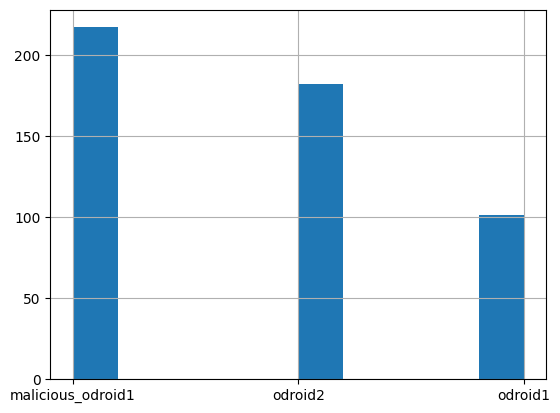

In [24]:
predictions.hist()